In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
import pandas as pd

rfm = pd.read_csv("../data/customer_segments.csv", index_col=0)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,2,Regular
12347.0,2,7,4310.00,1,High Value
12348.0,75,4,1797.24,2,Regular
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,3,At Risk


Segment Distribution

In [4]:
rfm['Segment'].value_counts()

Segment
At Risk       1594
Regular       1183
Occasional     839
High Value     723
Name: count, dtype: int64

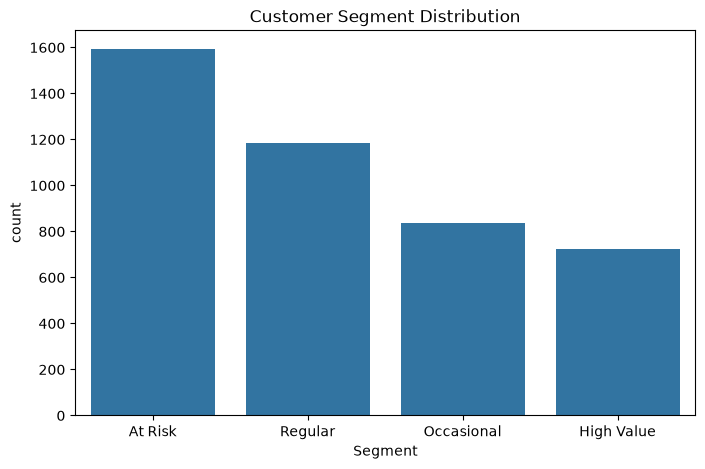

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=rfm,
    order=rfm['Segment'].value_counts().index
)

plt.title("Customer Segment Distribution")

plt.show()

 Cluster Profiles

In [6]:
cluster_profile = rfm.groupby('Segment')[
    ['Recency','Frequency','Monetary']
].mean()

cluster_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk,184.023839,1.318068,342.421268
High Value,12.112033,13.634855,8015.424412
Occasional,18.725864,2.090584,538.231287
Regular,70.697380,4.076923,1791.090873


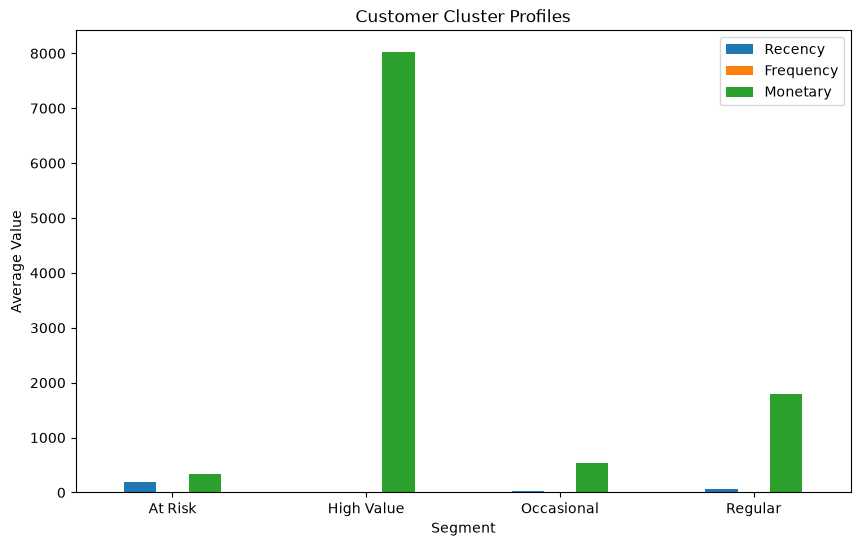

In [8]:

cluster_profile.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Customer Cluster Profiles")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.show()

Segment-wise Statistics

In [9]:

rfm.groupby('Segment').agg({
    'Recency':['mean','min','max'],
    'Frequency':['mean','min','max'],
    'Monetary':['mean','min','max']
})

Recency           Frequency              Monetary          \
                  mean min  max       mean min  max         mean     min   
Segment                                                                    
At Risk     184.023839  14  374   1.318068   1    6   342.421268    0.00   
High Value   12.112033   1  372  13.634855   2  210  8015.424412  808.62   
Occasional   18.725864   1   53   2.090584   1    7   538.231287   30.00   
Regular      70.697380   8  366   4.076923   1   14  1791.090873  322.41   

                       
                  max  
Segment                
At Risk       2169.39  
High Value  280206.02  
Occasional    3861.00  
Regular      77183.60

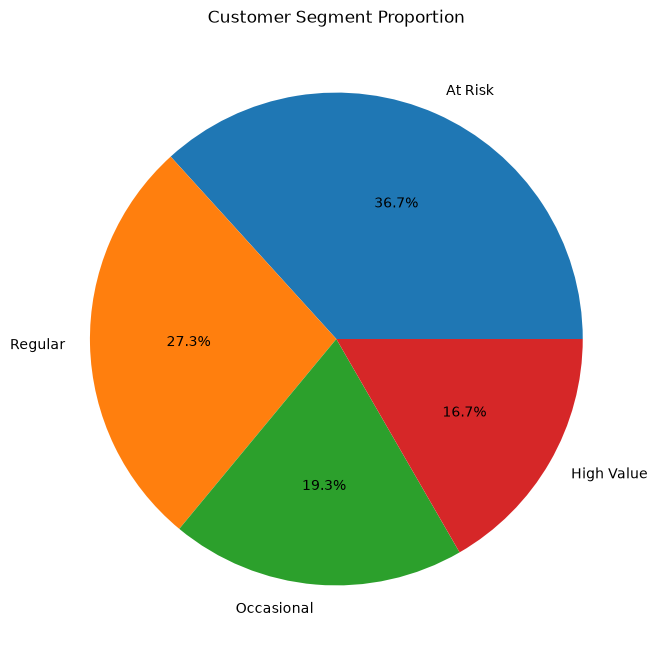

In [10]:
rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.ylabel('')

plt.title("Customer Segment Proportion")

plt.show()

In [ ]:
silhouette_scores = { # Silhouette Scores for K=2 to K=10
    2:0.433,
    3:0.336,
    4:0.336,
    5:0.316,
    6:0.305,
    7:0.309,
    8:0.274,
    9:0.276,
    10:0.278
}

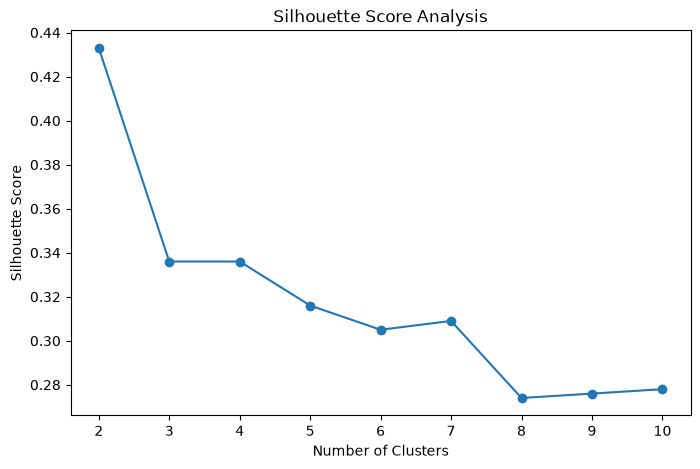

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    silhouette_scores.keys(),
    silhouette_scores.values(),
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score Analysis")

plt.show()

The Elbow Method suggested an optimal cluster range of 3–4 clusters. Although the highest silhouette score was obtained for k = 2, four clusters were chosen because they produced more interpretable customer segments and aligned better with business objectives.

Load Recommendation Model

In [13]:
similarity_df = pickle.load(
    open("../models/similarity.pkl",'rb')
)

In [14]:
def recommend(product, n=5):

    product = product.upper()

    if product not in similarity_df.index:
        return "Product not found"

    recommendations = (
        similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    return recommendations.index.tolist()

In [15]:
recommend("WHITE HANGING HEART T-LIGHT HOLDER")

['GIN + TONIC DIET METAL SIGN',
 'TEA TIME TEA TOWELS ',
 'FAIRY CAKE FLANNEL ASSORTED COLOUR',
 'DOORMAT FAIRY CAKE',
 'RED HANGING HEART T-LIGHT HOLDER']

## Business Insights

### High Value Customers
- Recent buyers
- Frequent purchasers
- Highest spending customers

### Regular Customers
- Moderate frequency and spending
- Potential to become High Value customers

### Occasional Customers
- Purchase infrequently
- Suitable targets for promotional campaigns

### At-Risk Customers
- Long time since last purchase
- Need retention strategies and personalized offers

## Conclusion

Customer segmentation was performed using the RFM model and KMeans clustering.

The Elbow Method and Silhouette Score were used to determine the optimal number of clusters.

Customers were grouped into:

1. High Value
2. Regular
3. Occasional
4. At Risk

An item-based collaborative filtering recommendation system using cosine similarity was implemented to recommend products similar to those previously purchased.

The developed system can help businesses improve customer retention, personalized marketing, and cross-selling opportunities.